Predicted 1:1 tongue: I in [1.5034, 1.6606]

Plateaus (rho, I range):
  rho = 0.0000   I in [0.900, 0.920]
  rho = 0.2500   I in [0.945, 0.965]
  rho = 0.3333   I in [0.975, 1.030]
  rho = 0.4000   I in [1.040, 1.055]
  rho = 0.5000   I in [1.080, 1.205]
  rho = 0.6000   I in [1.225, 1.240]
  rho = 0.6667   I in [1.260, 1.310]
  rho = 0.7500   I in [1.340, 1.365]
  rho = 0.8000   I in [1.385, 1.400]
  rho = 1.0000   I in [1.505, 1.660]
  rho = 2.0000   I in [2.535, 2.550]

Spike phase at I = 1.6: 0.1881 (spread 8.7e-15)


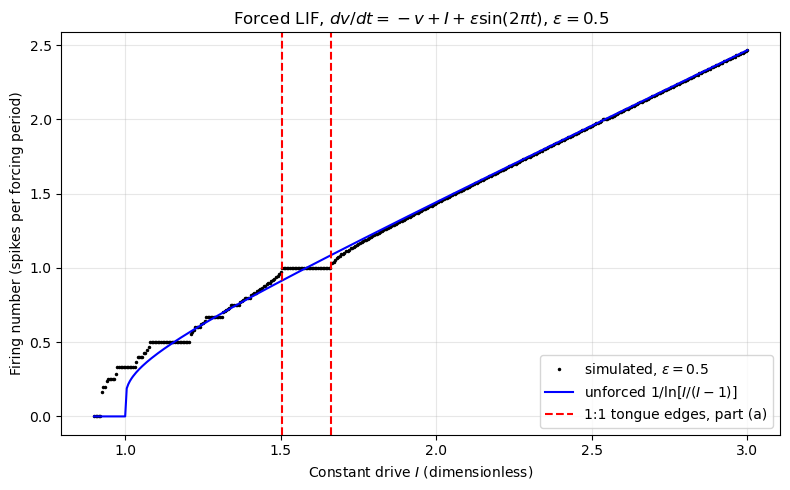

In [1]:
# APPM 4370 HW3, Problem 1(c): periodically forced LIF, firing number vs I
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

eps = 0.5              
dt = 1e-3              
T_transient = 100     
T_count = 420          

def G(t, I):
    return I + eps*(np.sin(2*np.pi*t) - 2*np.pi*np.cos(2*np.pi*t))/(1 + 4*np.pi**2)

def v(t, Tn, I):
    return G(t, I) - G(Tn, I)*np.exp(-(t - Tn))

def next_spike(Tn, I, t_end):
    t0 = Tn
    while t0 < t_end:
        t = t0 + dt*np.arange(1, 2001)          # check the next 2 periods on a grid
        above = np.nonzero(v(t, Tn, I) >= 1)[0]
        if len(above) > 0:
            k = above[0]
            a = Tn if k == 0 else t[k-1]
            return brentq(lambda s: v(s, Tn, I) - 1, a, t[k])   #crossing
        t0 = t[-1]
    return None

def spike_times(I):
    t_end = T_transient + T_count
    spikes, Tn = [], 0.0
    while True:
        Tn = next_spike(Tn, I, t_end)
        if Tn is None or Tn > t_end:
            return np.array(spikes)
        spikes.append(Tn)

def firing_number(I):
    s = spike_times(I)
    return np.sum(s > T_transient)/T_count      # spikes per forcing period

I_vals = np.linspace(0.9, 3.0, 421)
rho = np.array([firing_number(I) for I in I_vals])

# unforced firing number
rho0 = np.zeros_like(I_vals)
m = I_vals > 1
rho0[m] = 1/np.log(I_vals[m]/(I_vals[m] - 1))

# 1:1 tongue edges from part (a)
I_star = 1/(1 - np.exp(-1))
A = eps/np.sqrt(1 + 4*np.pi**2)
print(f"Predicted 1:1 tongue: I in [{I_star - A:.4f}, {I_star + A:.4f}]")

print("\nPlateaus (rho, I range):")
start = 0
for i in range(1, len(I_vals) + 1):
    if i == len(I_vals) or abs(rho[i] - rho[start]) > 1e-3:
        if i - start >= 3:          # at least 3 grid points wide
            print(f"  rho = {rho[start]:.4f}   I in [{I_vals[start]:.3f}, {I_vals[i-1]:.3f}]")
        start = i

s = spike_times(1.6)
ph = s[s > T_transient] % 1
print(f"\nSpike phase at I = 1.6: {ph.mean():.4f} (spread {ph.std():.1e})")

plt.figure(figsize=(8, 5))
plt.plot(I_vals, rho, 'k.', ms=3, label=r'simulated, $\varepsilon = 0.5$')
plt.plot(I_vals, rho0, 'b-', label=r'unforced $1/\ln[I/(I-1)]$')
plt.axvline(I_star - A, color='r', ls='--', label='1:1 tongue edges, part (a)')
plt.axvline(I_star + A, color='r', ls='--')
plt.xlabel('Constant drive $I$ (dimensionless)')
plt.ylabel('Firing number (spikes per forcing period)')
plt.title(r'Forced LIF, $dv/dt = -v + I + \varepsilon\sin(2\pi t)$, $\varepsilon = 0.5$')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()